# MERRA-2 Test

A little notebook where I will be testing downloads of subsets of MERRA-2 in Antarctica, and applying the AR catalog mask to look at some ARs.

## Loading up the MERRA-2 Data

Only loading up a couple of days during the March 2022 heatwave

In [1]:
import os
import xarray as xr
import csv
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

import matplotlib.animation as animation

In [2]:
path = '/home/jovyan/extreme_antarctic_ARs/data/merra2_practice/'
lst = os.listdir(path)

daily_xr_datasets = {}

for fname in lst:
    
    if 'MERRA2' in fname:
        daily_xr_datasets[fname] = xr.open_dataset(path + fname, engine='netcdf4')
        
tot_dataset = xr.concat(objs=list(daily_xr_datasets.values()), dim='time')

## Loading up the Relevant AR Catalogs

In [3]:
path = '~/extreme_antarctic_ARs/data/ar_catalogs/'
fn = 'MERRA2.ar_tag.Wille_v2.4_vIVT.3hourly.20220101-20221231.nc' # the files are annual, so this is just ARs in 1980
ar_catalog = xr.open_mfdataset(path+fn)
ar_binary_tag = ar_catalog.ar_binary_tag.sel(time=slice('2022-03-15T00:00','2022-03-18T23:00'))

In [4]:
tot_dataset

<xarray.Dataset>
Dimensions:  (time: 96, lat: 111, lon: 144)
Coordinates:
  * lat      (lat) float64 -90.0 -89.5 -89.0 -88.5 ... -36.5 -36.0 -35.5 -35.0
  * lon      (lon) float64 90.0 90.62 91.25 91.88 ... 177.5 178.1 178.8 179.4
  * time     (time) datetime64[ns] 2022-03-16 ... 2022-03-15T23:00:00
Data variables:
    TQV      (time, lat, lon) float32 0.5661 0.5661 0.5661 ... 23.53 24.06 25.38
    V10M     (time, lat, lon) float32 -2.782 -2.75 -2.717 ... 9.805 10.76 10.85
Attributes: (12/32)
    History:                           Original file generated: Sat Mar 26 22...
    Comment:                           GMAO filename: d5124_m2_jan10.inst1_2d...
    Filename:                          MERRA2_400.inst1_2d_asm_Nx.20220316.nc4
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    RangeBeginningDate:                2022-03-16
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2022-03-16
    RangeEndingTime:                   23:00:00.000000
    DODS_EXTRA.Unlimited_Dimension:    time
    history:                           2024-04-09 04:52:12 GMT Hyrax-1.16.3 h...

In [5]:
total_dat = xr.merge([ar_catalog, tot_dataset], join='inner')

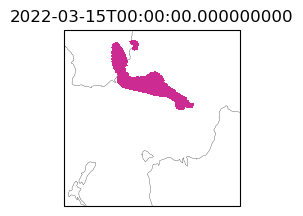

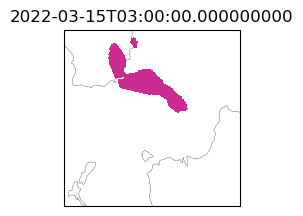

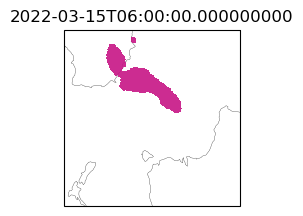

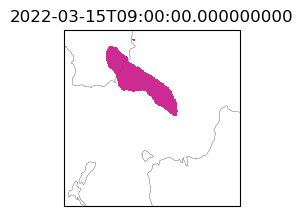

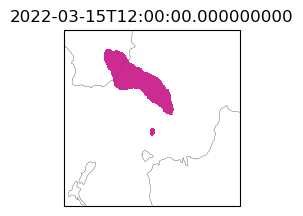

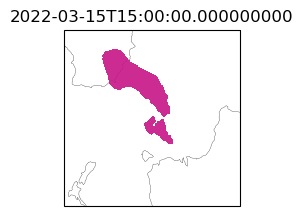

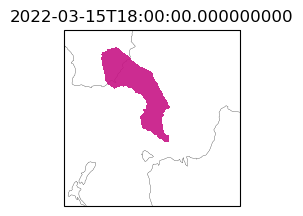

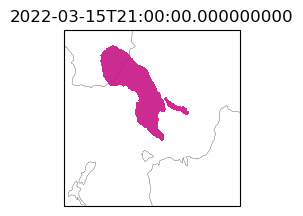

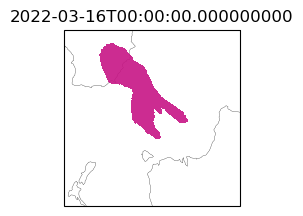

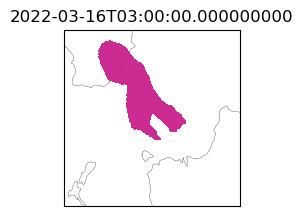

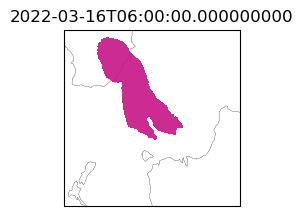

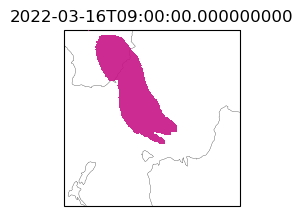

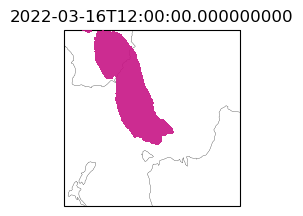

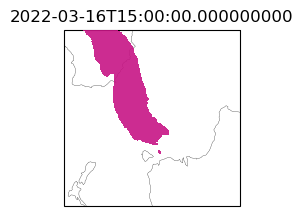

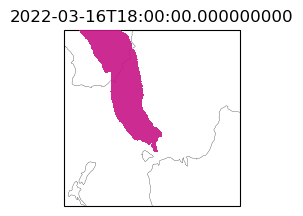

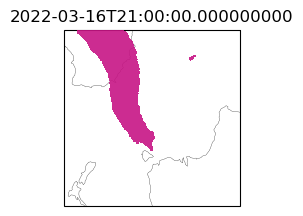

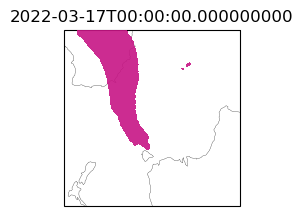

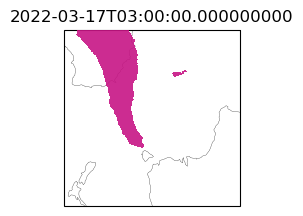

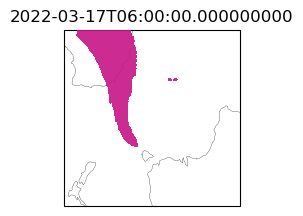

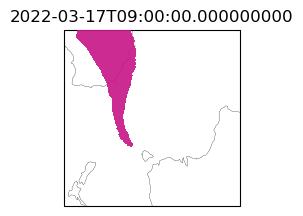

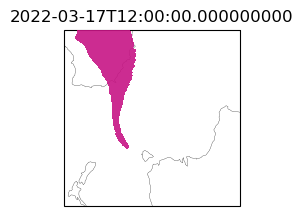

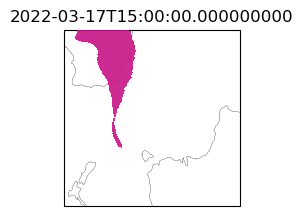

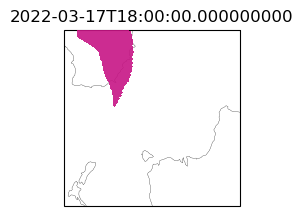

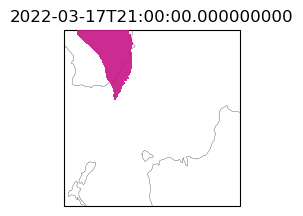

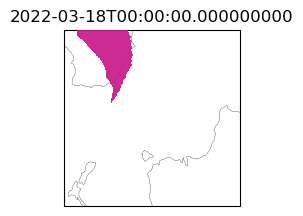

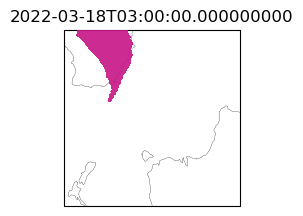

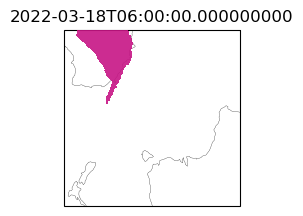

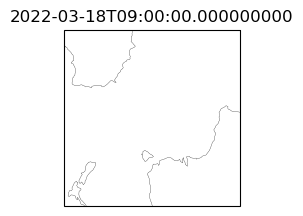

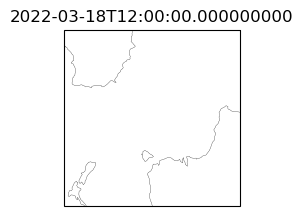

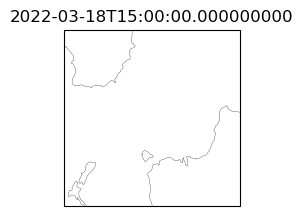

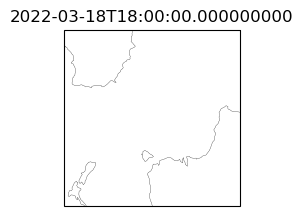

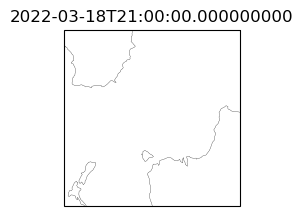

In [6]:
for i in range(len(ar_binary_tag.time)):
    plt.figure(figsize=(5,5))
    # Setting up the map - we're using a polar stereographic projection 
    ax1 = plt.subplot( 121, projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.) )
    ax1.set_extent([90,179.4,-90,-35], ccrs.PlateCarree())
    ax1.coastlines(resolution='110m',linewidth=0.2,zorder=14)
    # Plotting the ARs 
    colormap = matplotlib.colors.ListedColormap(['mediumvioletred'])
    levels = np.array([0.5,1.5]) # levels for the colormap 
    ax1.contourf(ar_binary_tag.lon,ar_binary_tag.lat,ar_binary_tag[i,:,:],levels,cmap=colormap,alpha=0.9,zorder=14,transform=ccrs.PlateCarree()) # cmap=colormap, Blues, YlGnBu_r, norm=matplotlib.colors.LogNorm()
    plt.title(ar_binary_tag.time[i].values) # plot the timestep 
    plt.show()

In [81]:
ar_dat = total_dat.where(total_dat.ar_binary_tag == 1)

In [7]:
type(ax1)

cartopy.mpl.geoaxes.GeoAxes

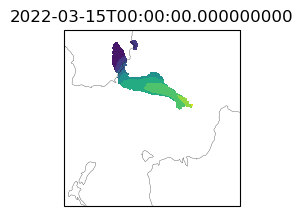

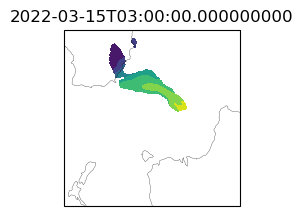

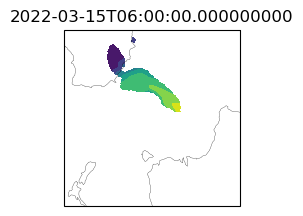

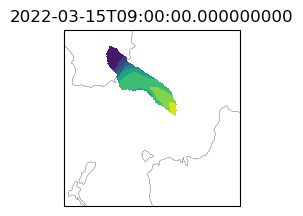

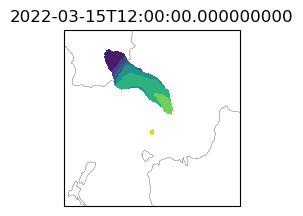

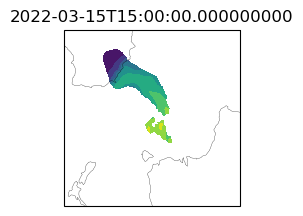

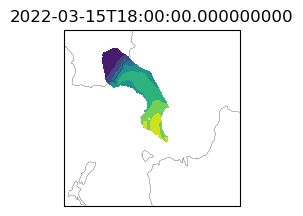

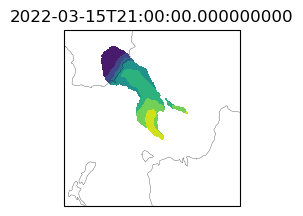

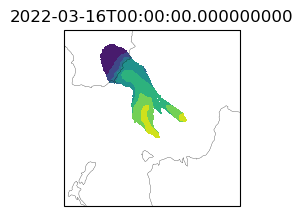

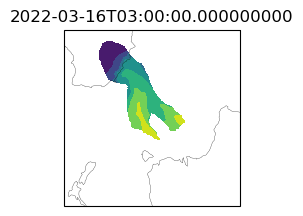

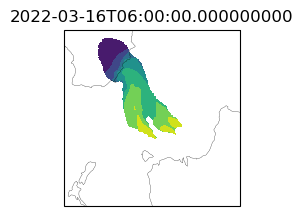

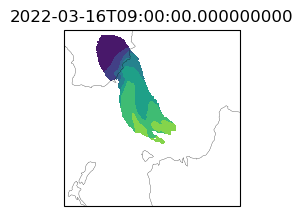

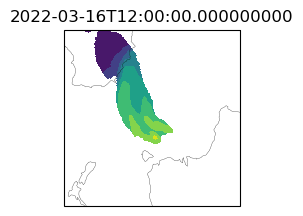

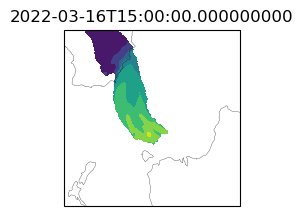

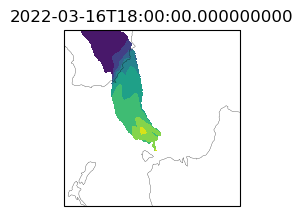

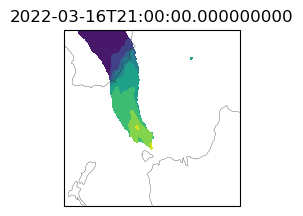

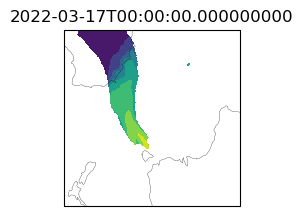

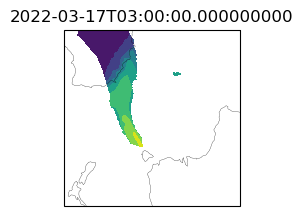

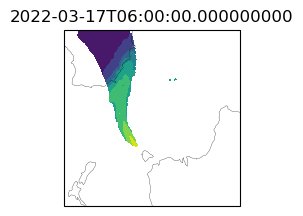

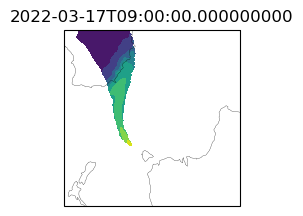

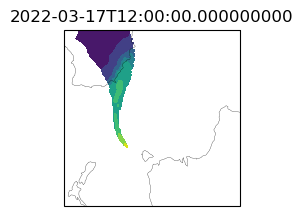

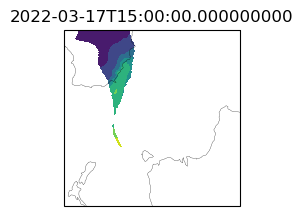

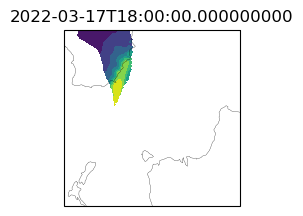

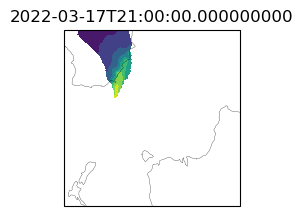

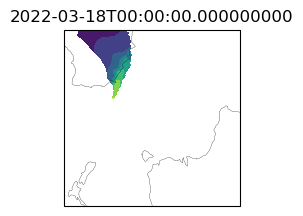

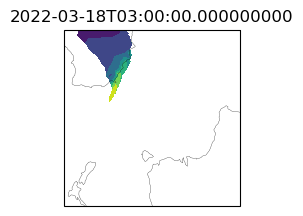

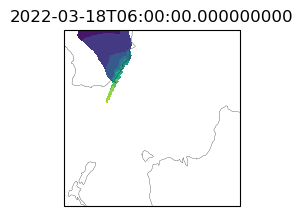

/srv/conda/envs/notebook/lib/python3.10/site-packages/matplotlib/contour.py:1454: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/srv/conda/envs/notebook/lib/python3.10/site-packages/matplotlib/contour.py:1455: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())


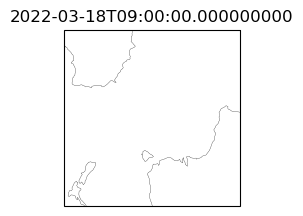

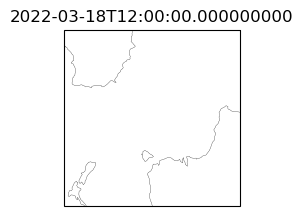

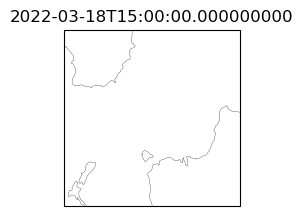

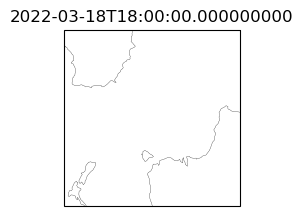

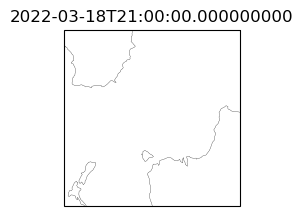

In [97]:
for i in range(len(ar_binary_tag.time)):
    plt.figure(figsize=(5,5))
    # Setting up the map - we're using a polar stereographic projection 
    ax1 = plt.subplot( 121, projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.) )
    ax1.set_extent([90,179.4,-90,-35], ccrs.PlateCarree())
    ax1.coastlines(resolution='110m',linewidth=0.2,zorder=14)
    # Plotting the ARs 
    colormap = matplotlib.colors.ListedColormap(['mediumvioletred']) 
    CS = ax1.contourf(ar_dat.lon,ar_dat.lat,ar_dat.TQV[i,:,:],transform=ccrs.PlateCarree()) # cmap=colormap, Blues, YlGnBu_r, norm=matplotlib.colors.LogNorm()
    # cbar = plt.colorbar(CS,fraction=0.04, pad=0.04) # we don't really need the colorbar plotted because it's a binary value
    plt.title(ar_binary_tag.time[i].values) # plot the timestep 
    plt.show()

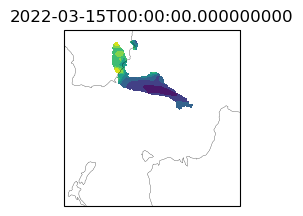

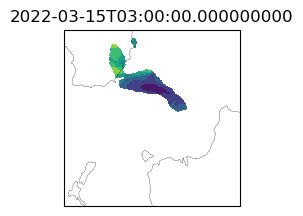

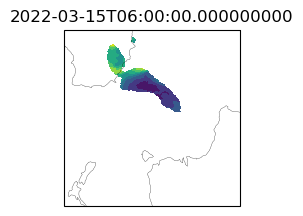

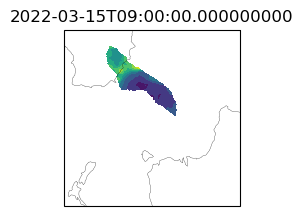

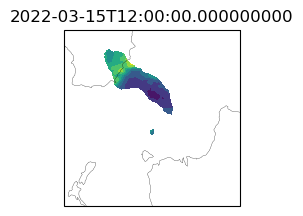

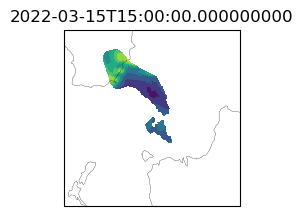

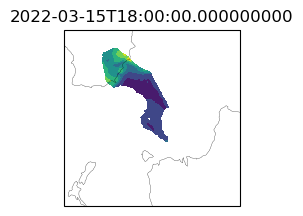

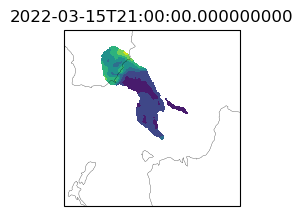

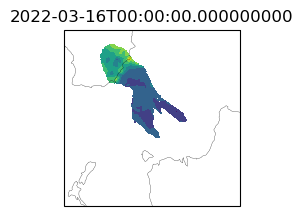

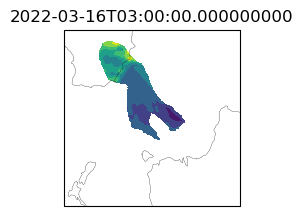

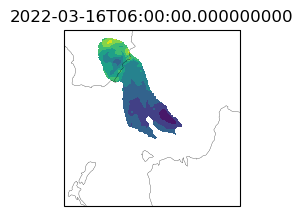

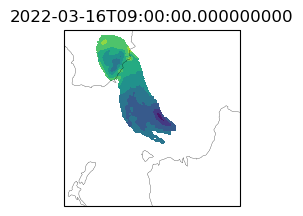

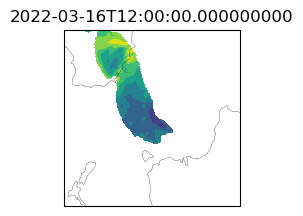

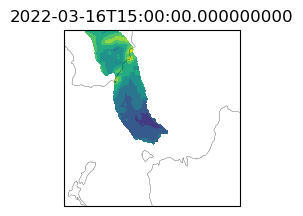

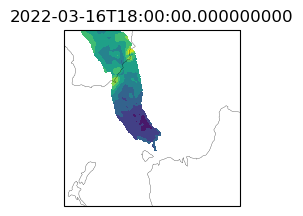

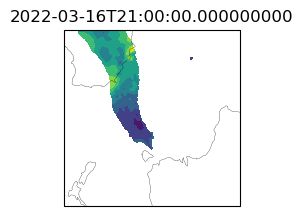

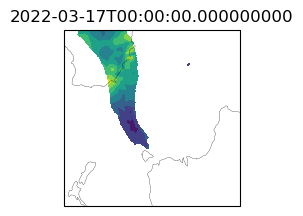

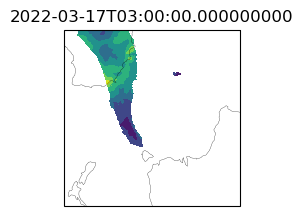

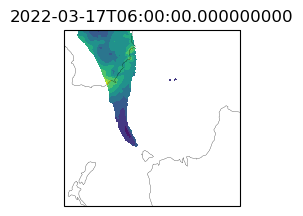

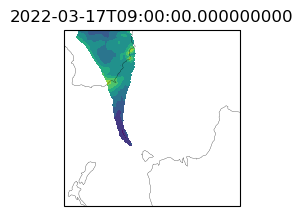

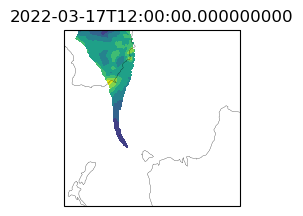

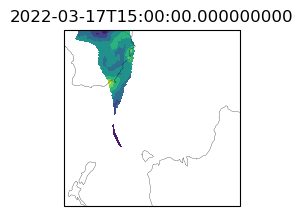

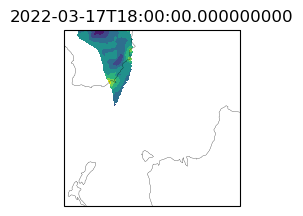

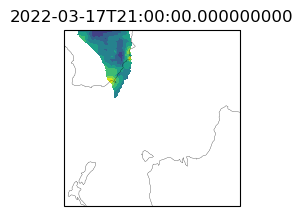

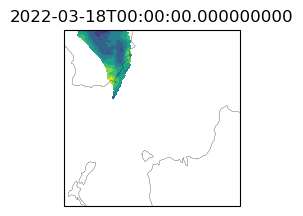

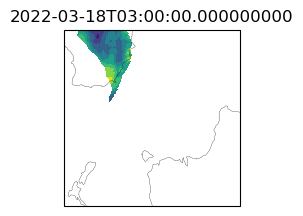

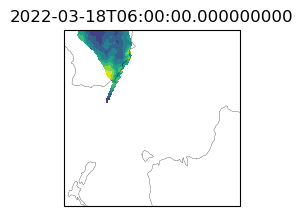

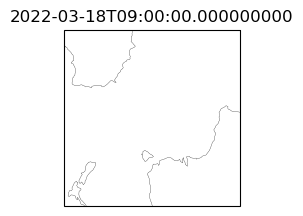

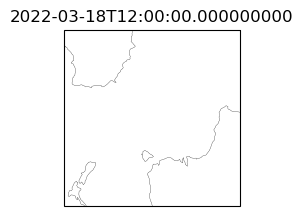

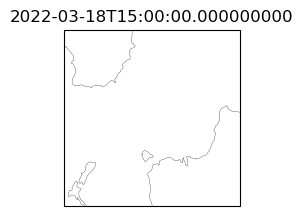

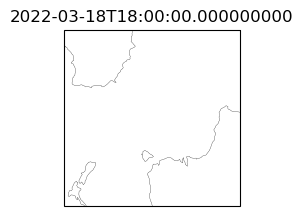

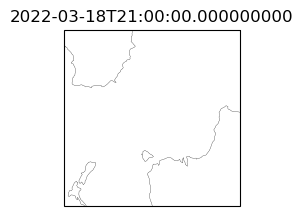

In [99]:
for i in range(len(ar_binary_tag.time)):
    plt.figure(figsize=(5,5))
    # Setting up the map - we're using a polar stereographic projection 
    ax1 = plt.subplot( 121, projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.) )
    ax1.set_extent([90,179.4,-90,-35], ccrs.PlateCarree())
    ax1.coastlines(resolution='110m',linewidth=0.2,zorder=14)
    # Plotting the ARs 
    colormap = matplotlib.colors.ListedColormap(['mediumvioletred']) 
    CS = ax1.contourf(ar_dat.lon,ar_dat.lat,ar_dat.V10M[i,:,:],transform=ccrs.PlateCarree()) # cmap=colormap, Blues, YlGnBu_r, norm=matplotlib.colors.LogNorm()
    # cbar = plt.colorbar(CS,fraction=0.04, pad=0.04) # we don't really need the colorbar plotted because it's a binary value
    plt.title(ar_binary_tag.time[i].values) # plot the timestep 
    plt.show()